# Task 6: Model Comparison

This notebook compares Logistic Regression, Decision Tree, and Random Forest with the original and improved eLCS systems. The experiments will use the preprocessed datasets exported in Task 3 and the eLCS results saved in the earlier tasks.



### 6.1 Import packages

This step imports the packages required for loading data, training the three conventional classification models, and evaluating their predictions.

- `Path` locates project files, while NumPy and pandas handle numerical arrays and datasets.
- `LogisticRegression`, `DecisionTreeClassifier`, and `RandomForestClassifier` provide the three models selected for comparison.
- `StandardScaler` and `make_pipeline` allow scaling to be fitted on the training data and applied consistently to the test data for Logistic Regression.
- The evaluation functions calculate accuracy, balanced accuracy, precision, recall, F1-score, ROC-AUC, average precision, and confusion matrices. Average precision will be reported as PR-AUC to match the earlier task notebooks.
- `time` measures training duration, and `display` presents result tables.

Importing these packages does not load datasets or train any models.



In [3]:
# Imports for Task 6: Model Comparison
from pathlib import Path
import time

import numpy as np
import pandas as pd
from IPython.display import display

# Conventional classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Training-fitted scaling for Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


### 6.2 Load the preprocessed datasets

The undersampled training predictors and target labels exported in Task 3 are loaded for the three conventional models. These are the same training records used by the improved eLCS system in Task 4.

The preprocessed test predictors and target labels are loaded separately. The test set retains its original records and class distribution; it is not undersampled. Encoding and discretisation have already been applied in Task 3, so they are not repeated here.

The code locates the project data folder, reads the four CSV files, and displays the dataset dimensions and target-class counts. Target value 0 represents no heart disease, while target value 1 represents heart disease.


In [4]:
# Locates the project root from either notebook folder or the repository root.
if Path.cwd().name in {'notebooks', 'notebooks-phase2'}:
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data'

# Loads the undersampled training predictors and target labels.
X_train_undersampled = pd.read_csv(
    DATA_DIR / 'X_train_preprocessed_undersampled.csv'
)
y_train_undersampled = pd.read_csv(
    DATA_DIR / 'y_train_preprocessed_undersampled.csv'
).squeeze('columns')

# Loads the preprocessed test set without changing its class distribution.
X_test = pd.read_csv(
    DATA_DIR / 'X_test_preprocessed.csv'
)
y_test = pd.read_csv(
    DATA_DIR / 'y_test_preprocessed.csv'
).squeeze('columns')

print('Data folder:', DATA_DIR)
print('Undersampled training shape:', X_train_undersampled.shape)
print('Training target shape:', y_train_undersampled.shape)
print('Testing shape:', X_test.shape)
print('Testing target shape:', y_test.shape)

print()
print('Undersampled training target distribution (0 = no heart disease, 1 = heart disease):')
print(y_train_undersampled.value_counts().sort_index())

print()
print('Testing target distribution (0 = no heart disease, 1 = heart disease):')
print(y_test.value_counts().sort_index())


Data folder: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\data
Undersampled training shape: (29713, 34)
Training target shape: (29713,)
Testing shape: (55741, 34)
Testing target shape: (55741,)

Undersampled training target distribution (0 = no heart disease, 1 = heart disease):
heart_disease_target
0    25000
1     4713
Name: count, dtype: int64

Testing target distribution (0 = no heart disease, 1 = heart disease):
heart_disease_target
0    54563
1     1178
Name: count, dtype: int64


### 6.3 Check the data

Before model training, the training and testing predictors are checked to confirm that they contain the same feature columns in the same order. Each predictor dataset is also checked to ensure its row count matches its corresponding target labels.

Missing values are checked separately in the training predictors, training targets, testing predictors, and testing targets. If any check fails, the code stops so that the issue can be investigated before training.

In [5]:
# Check that predictor columns match, including their order.
assert list(X_train_undersampled.columns) == list(X_test.columns)

# Check predictor/target row counts.
assert len(X_train_undersampled) == len(y_train_undersampled)
assert len(X_test) == len(y_test)

# Check for missing values.
assert not X_train_undersampled.isna().any().any()
assert not y_train_undersampled.isna().any()
assert not X_test.isna().any().any()
assert not y_test.isna().any()

print("All data checks passed.")

All data checks passed.


### 6.4 Define model settings and experimental seeds

The experiments use seeds [3, 6, 9, 12, 15, 18, 21, 24, 27, 30], matching Task 4. The saved training and testing datasets remain fixed; the seeds control model randomness rather than changing the split or undersampling.

Each model uses the same parameter settings across all ten runs. Logistic Regression uses training-fitted standardisation and a maximum of 2,000 optimisation iterations to allow convergence. Decision Tree uses its default configuration, while Random Forest uses 100 trees. No additional class weighting is applied because the training dataset has already been undersampled.

A fresh model is created for each run. Logistic Regression uses the deterministic lbfgs solver, so changing its random seed may produce identical results on these fixed datasets.

In [6]:
# Same seeds as Task 4.
SEEDS = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

# Settings remain constant across runs.
LOGISTIC_SETTINGS = {
    "solver": "lbfgs",
    "max_iter": 2000,
    "C": 1.0,
    "class_weight": None,
}

TREE_SETTINGS = {
    "criterion": "gini",
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "class_weight": None,
}

FOREST_SETTINGS = {
    "n_estimators": 100,
    "criterion": "gini",
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "class_weight": None,
    "n_jobs": -1,
}


def create_models(seed):
    # Returns fresh, untrained models for the selected seed.
    return {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                random_state=seed,
                **LOGISTIC_SETTINGS,
            ),
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=seed,
            **TREE_SETTINGS,
        ),
        "Random Forest": RandomForestClassifier(
            random_state=seed,
            **FOREST_SETTINGS,
        ),
    }


print("Experimental seeds:", SEEDS)
print("Logistic Regression settings:", LOGISTIC_SETTINGS)
print("Decision Tree settings:", TREE_SETTINGS)
print("Random Forest settings:", FOREST_SETTINGS)

Experimental seeds: [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
Logistic Regression settings: {'solver': 'lbfgs', 'max_iter': 2000, 'C': 1.0, 'class_weight': None}
Decision Tree settings: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': None}
Random Forest settings: {'n_estimators': 100, 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': None, 'n_jobs': -1}


### 6.5 Train and evaluate Logistic Regression

Logistic Regression is trained on the fixed undersampled training dataset for each of the ten seeds. The pipeline fits standardisation on the training data and applies the same transformation to the test data.

Each run records training time and evaluates test predictions using accuracy, balanced accuracy, precision, recall, F1-score, ROC-AUC, average precision (reported as PR-AUC), and confusion-matrix counts. Results are saved after each completed run.

The datasets and model settings remain fixed. Because the lbfgs solver is deterministic, predictive metrics may be identical across seeds. A convergence warning stops the run so that an unfinished optimisation is not silently accepted.

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logistic_results = []

for seed in SEEDS:
    print(f"Logistic Regression: starting seed {seed}", flush=True)

    # Creates a fresh pipeline with the settings defined in Section 6.4.
    model = create_models(seed)["Logistic Regression"]

    # Measures fitting time, including training-fitted standardisation.
    start_time = time.perf_counter()

    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train_undersampled, y_train_undersampled)

    training_seconds = time.perf_counter() - start_time

    # Generates class predictions and probabilities of heart disease.
    predictions = model.predict(X_test)
    positive_column = np.flatnonzero(model.classes_ == 1)[0]
    probabilities = model.predict_proba(X_test)[:, positive_column]

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    ).ravel()

    result = {
        "Model": "Logistic Regression",
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        # Matches the average-precision definition in Tasks 2 and 4.
        "PR-AUC": average_precision_score(y_test, probabilities),
        "True negatives": int(tn),
        "False positives": int(fp),
        "False negatives": int(fn),
        "True positives": int(tp),
        "Positive predictions": int((predictions == 1).sum()),
        "Training seconds": training_seconds,
    }

    logistic_results.append(result)

    # Saves completed runs so progress is retained.
    logistic_runs_df = pd.DataFrame(logistic_results)
    logistic_runs_df.to_csv(
        OUTPUT_DIR / "logistic_regression_runs.csv",
        index=False,
    )

    print(
        f"Completed seed {seed}: "
        f"balanced accuracy={result['Balanced accuracy']:.4f}, "
        f"recall={result['Recall']:.4f}, "
        f"precision={result['Precision']:.4f}",
        flush=True,
    )

display(logistic_runs_df)

# Summarises the ten runs.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Training seconds",
]

logistic_summary = (
    logistic_runs_df[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .transpose()
    .rename_axis("Metric")
    .reset_index()
)

display(logistic_summary)

logistic_summary.to_csv(
    OUTPUT_DIR / "logistic_regression_summary.csv",
    index=False,
)

print("Results saved to:", OUTPUT_DIR)

Logistic Regression: starting seed 3
Completed seed 3: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 6
Completed seed 6: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 9
Completed seed 9: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 12
Completed seed 12: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 15
Completed seed 15: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 18
Completed seed 18: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 21
Completed seed 21: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 24
Completed seed 24: balanced accuracy=0.6254, recall=0.2844, precision=0.1548
Logistic Regression: starting seed 27
Completed seed 27: balanced accuracy=0.6254, rec

,Model,Seed,Accuracy,Precision,Recall,F1,Balanced accuracy,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Positive predictions,Training seconds
0,Logistic Regression,3,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.330943
1,Logistic Regression,6,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.215188
2,Logistic Regression,9,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.350887
3,Logistic Regression,12,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.246385
4,Logistic Regression,15,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.242352
5,Logistic Regression,18,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.220987
6,Logistic Regression,21,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.214661
7,Logistic Regression,24,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.198581
8,Logistic Regression,27,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.200716
9,Logistic Regression,30,0.952064,0.154806,0.28438,0.200479,0.62543,0.87639,0.124663,52734,1829,843,335,2164,0.248350


,Metric,mean,std,min,max
0,Accuracy,0.952064,0.000000e+00,0.952064,0.952064
1,Precision,0.154806,0.000000e+00,0.154806,0.154806
2,Recall,0.284380,0.000000e+00,0.284380,0.284380
3,F1,0.200479,2.925695e-17,0.200479,0.200479
4,Balanced accuracy,0.625430,0.000000e+00,0.625430,0.625430
5,ROC-AUC,0.876390,1.170278e-16,0.876390,0.876390
6,PR-AUC,0.124663,1.462847e-17,0.124663,0.124663
7,Training seconds,0.246905,5.279268e-02,0.198581,0.350887


Results saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison


### 6.6 Train and evaluate Decision Tree

Decision Tree is trained on the same fixed undersampled training data and evaluated on the same test set as Logistic Regression and improved eLCS.

Each of the ten runs uses a fresh model with the settings defined in Section 6.4, changing only the random seed. The seed controls randomness during tree construction, including choosing between equally good splits.

The same evaluation metrics and training time are recorded, and results are saved after each completed run.

In [8]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

decision_tree_results = []

for seed in SEEDS:
    print(f"Decision Tree: starting seed {seed}", flush=True)

    # Creates a fresh tree with the settings defined in Section 6.4.
    model = create_models(seed)["Decision Tree"]

    start_time = time.perf_counter()
    model.fit(X_train_undersampled, y_train_undersampled)
    training_seconds = time.perf_counter() - start_time

    # Generates class predictions and probabilities of heart disease.
    predictions = model.predict(X_test)
    positive_column = np.flatnonzero(model.classes_ == 1)[0]
    probabilities = model.predict_proba(X_test)[:, positive_column]

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    ).ravel()

    result = {
        "Model": "Decision Tree",
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
        "True negatives": int(tn),
        "False positives": int(fp),
        "False negatives": int(fn),
        "True positives": int(tp),
        "Positive predictions": int((predictions == 1).sum()),
        "Training seconds": training_seconds,
    }

    decision_tree_results.append(result)

    # Saves completed runs so progress is retained.
    decision_tree_runs_df = pd.DataFrame(decision_tree_results)
    decision_tree_runs_df.to_csv(
        OUTPUT_DIR / "decision_tree_runs.csv",
        index=False,
    )

    print(
        f"Completed seed {seed}: "
        f"balanced accuracy={result['Balanced accuracy']:.4f}, "
        f"recall={result['Recall']:.4f}, "
        f"precision={result['Precision']:.4f}",
        flush=True,
    )

display(decision_tree_runs_df)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Training seconds",
]

decision_tree_summary = (
    decision_tree_runs_df[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .transpose()
    .rename_axis("Metric")
    .reset_index()
)

display(decision_tree_summary)

decision_tree_summary.to_csv(
    OUTPUT_DIR / "decision_tree_summary.csv",
    index=False,
)

print("Results saved to:", OUTPUT_DIR)

Decision Tree: starting seed 3
Completed seed 3: balanced accuracy=0.7356, recall=0.5323, precision=0.1585
Decision Tree: starting seed 6
Completed seed 6: balanced accuracy=0.7368, recall=0.5340, precision=0.1602
Decision Tree: starting seed 9
Completed seed 9: balanced accuracy=0.7412, recall=0.5433, precision=0.1617
Decision Tree: starting seed 12
Completed seed 12: balanced accuracy=0.7414, recall=0.5433, precision=0.1624
Decision Tree: starting seed 15
Completed seed 15: balanced accuracy=0.7371, recall=0.5348, precision=0.1599
Decision Tree: starting seed 18
Completed seed 18: balanced accuracy=0.7372, recall=0.5348, precision=0.1606
Decision Tree: starting seed 21
Completed seed 21: balanced accuracy=0.7369, recall=0.5348, precision=0.1593
Decision Tree: starting seed 24
Completed seed 24: balanced accuracy=0.7377, recall=0.5357, precision=0.1609
Decision Tree: starting seed 27
Completed seed 27: balanced accuracy=0.7362, recall=0.5331, precision=0.1594
Decision Tree: starting s

,Model,Seed,Accuracy,Precision,Recall,F1,Balanced accuracy,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Positive predictions,Training seconds
0,Decision Tree,3,0.930392,0.158493,0.532258,0.244254,0.735623,0.854089,0.132446,51234,3329,551,627,3956,0.213366
1,Decision Tree,6,0.931002,0.160214,0.533956,0.246473,0.736765,0.854605,0.134305,51266,3297,549,629,3926,0.372856
2,Decision Tree,9,0.930805,0.161657,0.543294,0.249173,0.741232,0.858581,0.137211,51244,3319,538,640,3959,0.268505
3,Decision Tree,12,0.931128,0.162395,0.543294,0.250049,0.741397,0.859517,0.137905,51262,3301,538,640,3941,0.331166
4,Decision Tree,15,0.930769,0.159858,0.534805,0.246142,0.737061,0.855404,0.133939,51252,3311,548,630,3941,0.165402
5,Decision Tree,18,0.931074,0.160550,0.534805,0.246962,0.737217,0.856586,0.135624,51269,3294,548,630,3924,0.168241
6,Decision Tree,21,0.930500,0.159252,0.534805,0.245423,0.736924,0.855650,0.133574,51237,3326,548,630,3956,0.553746
7,Decision Tree,24,0.931146,0.160887,0.535654,0.247451,0.737669,0.855766,0.135436,51272,3291,547,631,3922,0.401034
8,Decision Tree,27,0.930715,0.159391,0.533107,0.245408,0.736203,0.854439,0.133395,51251,3312,550,628,3940,0.250543
9,Decision Tree,30,0.930518,0.158774,0.532258,0.244587,0.735687,0.853392,0.132798,51241,3322,551,627,3949,0.554043


,Metric,mean,std,min,max
0,Accuracy,0.930805,0.000276,0.930392,0.931146
1,Precision,0.160147,0.001253,0.158493,0.162395
2,Recall,0.535823,0.004097,0.532258,0.543294
3,F1,0.246592,0.001884,0.244254,0.250049
4,Balanced accuracy,0.737578,0.002074,0.735623,0.741397
5,ROC-AUC,0.855803,0.001954,0.853392,0.859517
6,PR-AUC,0.134663,0.001837,0.132446,0.137905
7,Training seconds,0.327890,0.143005,0.165402,0.554043


Results saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison


### 6.7 Train and evaluate Random Forest

Random Forest is trained on the same fixed undersampled training data and evaluated on the same test set as the other models.

Each run creates a fresh forest using the settings defined in Section 6.4, including 100 trees. Only the random seed changes, controlling the random sampling of training records and features during tree construction.

The same evaluation metrics and training time are recorded. Results are saved after each completed run, followed by summary statistics across all ten seeds.

In [9]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random_forest_results = []

for seed in SEEDS:
    print(f"Random Forest: starting seed {seed}", flush=True)

    # Creates a fresh forest with the settings defined in Section 6.4.
    model = create_models(seed)["Random Forest"]

    start_time = time.perf_counter()
    model.fit(X_train_undersampled, y_train_undersampled)
    training_seconds = time.perf_counter() - start_time

    # Generates class predictions and probabilities of heart disease.
    predictions = model.predict(X_test)
    positive_column = np.flatnonzero(model.classes_ == 1)[0]
    probabilities = model.predict_proba(X_test)[:, positive_column]

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    ).ravel()

    result = {
        "Model": "Random Forest",
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
        "True negatives": int(tn),
        "False positives": int(fp),
        "False negatives": int(fn),
        "True positives": int(tp),
        "Positive predictions": int((predictions == 1).sum()),
        "Training seconds": training_seconds,
    }

    random_forest_results.append(result)

    # Saves completed runs so progress is retained.
    random_forest_runs_df = pd.DataFrame(random_forest_results)
    random_forest_runs_df.to_csv(
        OUTPUT_DIR / "random_forest_runs.csv",
        index=False,
    )

    print(
        f"Completed seed {seed}: "
        f"balanced accuracy={result['Balanced accuracy']:.4f}, "
        f"recall={result['Recall']:.4f}, "
        f"precision={result['Precision']:.4f}",
        flush=True,
    )

display(random_forest_runs_df)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Training seconds",
]

random_forest_summary = (
    random_forest_runs_df[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .transpose()
    .rename_axis("Metric")
    .reset_index()
)

display(random_forest_summary)

random_forest_summary.to_csv(
    OUTPUT_DIR / "random_forest_summary.csv",
    index=False,
)

print("Results saved to:", OUTPUT_DIR)

Random Forest: starting seed 3
Completed seed 3: balanced accuracy=0.7908, recall=0.6511, precision=0.1684
Random Forest: starting seed 6
Completed seed 6: balanced accuracy=0.7824, recall=0.6324, precision=0.1682
Random Forest: starting seed 9
Completed seed 9: balanced accuracy=0.7926, recall=0.6545, precision=0.1692
Random Forest: starting seed 12
Completed seed 12: balanced accuracy=0.7898, recall=0.6486, precision=0.1687
Random Forest: starting seed 15
Completed seed 15: balanced accuracy=0.7890, recall=0.6469, precision=0.1687
Random Forest: starting seed 18
Completed seed 18: balanced accuracy=0.7800, recall=0.6290, precision=0.1645
Random Forest: starting seed 21
Completed seed 21: balanced accuracy=0.7908, recall=0.6511, precision=0.1681
Random Forest: starting seed 24
Completed seed 24: balanced accuracy=0.7897, recall=0.6486, precision=0.1684
Random Forest: starting seed 27
Completed seed 27: balanced accuracy=0.7867, recall=0.6409, precision=0.1700
Random Forest: starting s

,Model,Seed,Accuracy,Precision,Recall,F1,Balanced accuracy,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Positive predictions,Training seconds
0,Random Forest,3,0.924687,0.168423,0.651104,0.267620,0.790849,0.927952,0.169233,50776,3787,411,767,4554,1.988037
1,Random Forest,6,0.926123,0.168172,0.632428,0.265692,0.782446,0.926580,0.165773,50878,3685,433,745,4430,1.547148
2,Random Forest,9,0.924795,0.169227,0.654499,0.268922,0.792565,0.926799,0.169175,50778,3785,407,771,4556,2.227363
3,Random Forest,12,0.925046,0.168728,0.648557,0.267788,0.789786,0.926161,0.167497,50799,3764,414,764,4528,2.076839
4,Random Forest,15,0.925190,0.168733,0.646859,0.267650,0.789029,0.926563,0.166583,50809,3754,416,762,4516,1.943197
5,Random Forest,18,0.924634,0.164484,0.629032,0.260778,0.780024,0.927128,0.167078,50799,3764,437,741,4505,1.616217
6,Random Forest,21,0.924544,0.168128,0.651104,0.267247,0.790775,0.927112,0.167572,50768,3795,411,767,4562,1.579381
7,Random Forest,24,0.924903,0.168430,0.648557,0.267413,0.789713,0.926980,0.169373,50791,3772,414,764,4536,1.538697
8,Random Forest,27,0.926266,0.169968,0.640917,0.268683,0.786672,0.925958,0.168599,50876,3687,423,755,4442,1.432892
9,Random Forest,30,0.925495,0.168487,0.641766,0.266902,0.786693,0.927495,0.167803,50832,3731,422,756,4487,1.707005


,Metric,mean,std,min,max
0,Accuracy,0.925168,0.000611,0.924544,0.926266
1,Precision,0.168278,0.001441,0.164484,0.169968
2,Recall,0.644482,0.008373,0.629032,0.654499
3,F1,0.266870,0.002320,0.260778,0.268922
4,Balanced accuracy,0.787855,0.003966,0.780024,0.792565
5,ROC-AUC,0.926873,0.000598,0.925958,0.927952
6,PR-AUC,0.167869,0.001214,0.165773,0.169373
7,Training seconds,1.765678,0.271097,1.432892,2.227363


Results saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison


### 6.8 Compare predictive metrics across models

Bar charts compare balanced accuracy, recall, precision, F1-score, and PR-AUC across the six model configurations. Bars represent the mean across ten runs, while error bars represent one standard deviation.

For the preprocessed models, variation reflects model randomness on fixed datasets. The raw eLCS baseline used different train/test splits across seeds, so its variation reflects a different experimental protocol.

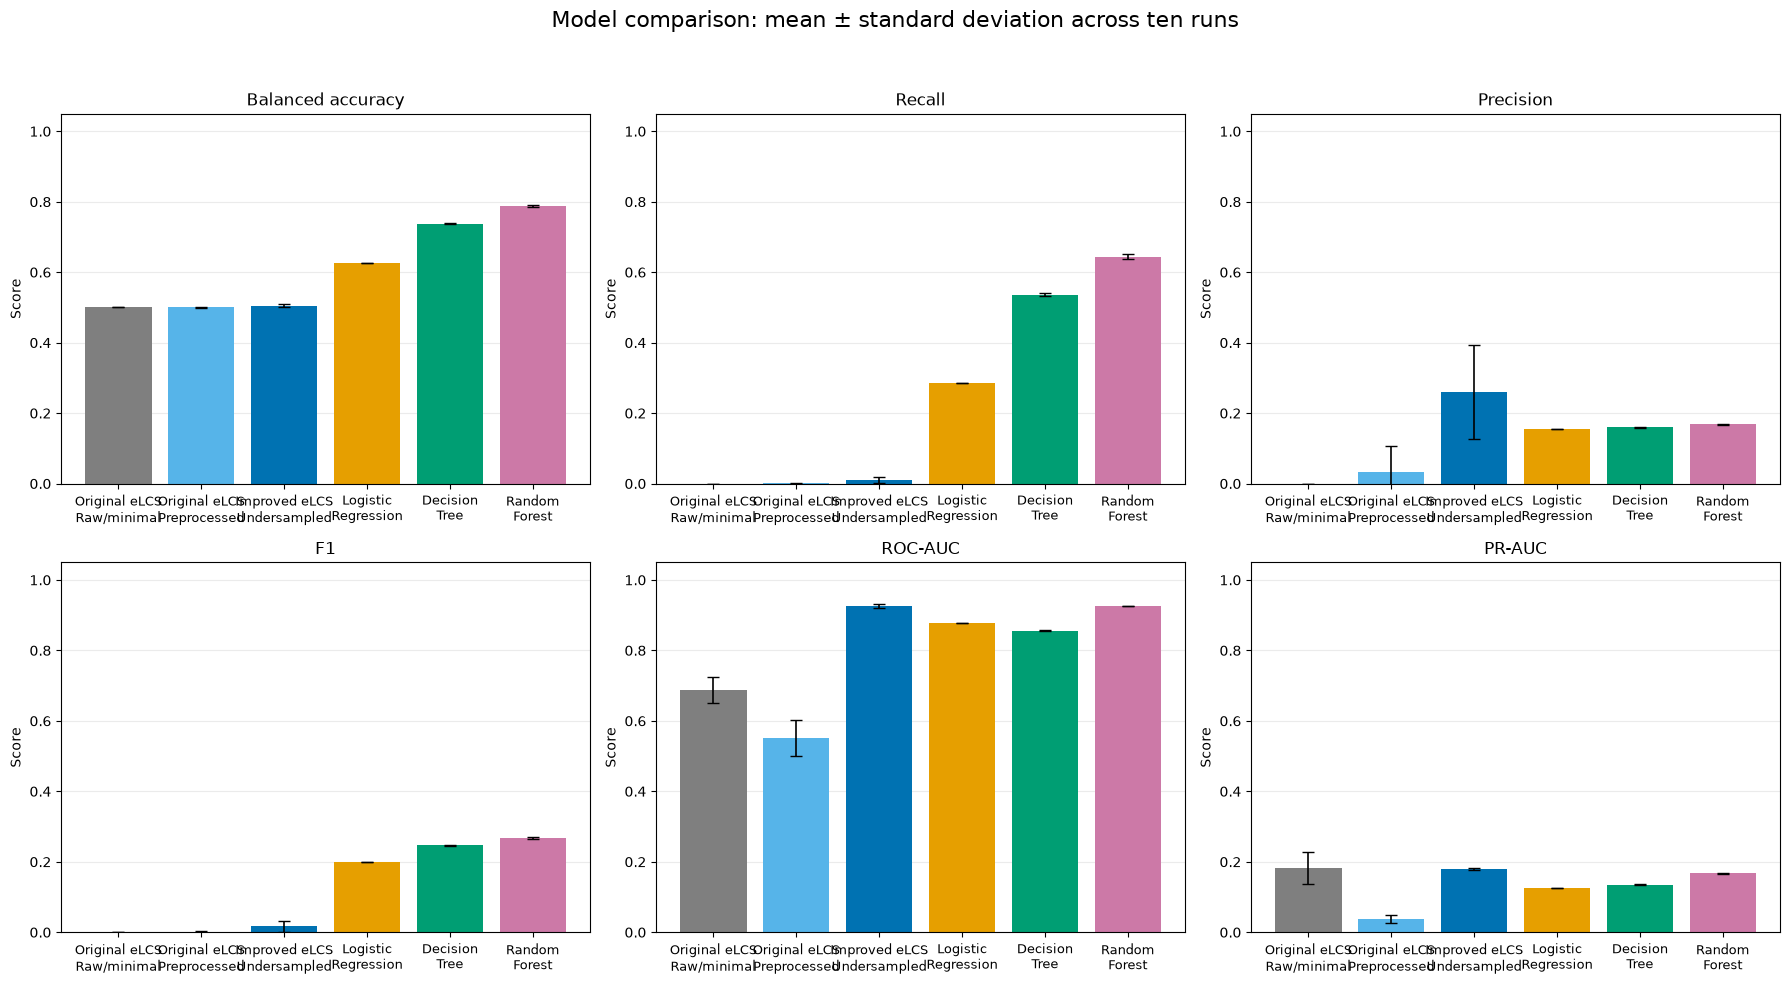

Graph saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison\metric_comparison_error_bars.png


,Balanced accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC
Original eLCS\nRaw/minimal,0.5000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.6868 ± 0.0374,0.1825 ± 0.0461
Original eLCS\nPreprocessed,0.5003 ± 0.0007,0.0006 ± 0.0016,0.0322 ± 0.0738,0.0012 ± 0.0031,0.5514 ± 0.0522,0.0376 ± 0.0113
Improved eLCS\nUndersampled,0.5044 ± 0.0041,0.0093 ± 0.0088,0.2597 ± 0.1333,0.0175 ± 0.0159,0.9259 ± 0.0049,0.1783 ± 0.0029
Logistic\nRegression,0.6254 ± 0.0000,0.2844 ± 0.0000,0.1548 ± 0.0000,0.2005 ± 0.0000,0.8764 ± 0.0000,0.1247 ± 0.0000
Decision\nTree,0.7376 ± 0.0021,0.5358 ± 0.0041,0.1601 ± 0.0013,0.2466 ± 0.0019,0.8558 ± 0.0020,0.1347 ± 0.0018
Random\nForest,0.7879 ± 0.0040,0.6445 ± 0.0084,0.1683 ± 0.0014,0.2669 ± 0.0023,0.9269 ± 0.0006,0.1679 ± 0.0012


In [16]:
import matplotlib.pyplot as plt

# Loads individual runs, rather than the already aggregated summaries.
result_files = {
    "Original eLCS\nRaw/minimal":
        PROJECT_ROOT / "outputs" / "original_elcs_baseline"
        / "baseline_runs.csv",

    "Original eLCS\nPreprocessed":
        PROJECT_ROOT / "outputs" / "improved_elcs_undersampling"
        / "full_preprocessed_default_runs.csv",

    "Improved eLCS\nUndersampled":
        PROJECT_ROOT / "outputs" / "improved_elcs_undersampling"
        / "undersampled_improved_elcs_runs.csv",

    "Logistic\nRegression":
        PROJECT_ROOT / "outputs" / "model_comparison"
        / "logistic_regression_runs.csv",

    "Decision\nTree":
        PROJECT_ROOT / "outputs" / "model_comparison"
        / "decision_tree_runs.csv",

    "Random\nForest":
        PROJECT_ROOT / "outputs" / "model_comparison"
        / "random_forest_runs.csv",
}

comparison_metrics = [
    "Balanced accuracy",
    "Recall",
    "Precision",
    "F1",
    "ROC-AUC",
    "PR-AUC",
]

# Checks that every model has a saved results file.
missing_files = [
    str(path) for path in result_files.values()
    if not path.exists()
]
if missing_files:
    raise FileNotFoundError(
        "Complete the model experiments first. Missing files:\n"
        + "\n".join(missing_files)
    )

# Loads and validates the ten-run results.
model_results = {}

for model_name, path in result_files.items():
    results = pd.read_csv(path)

    assert len(results) == len(SEEDS), (
        f"{model_name}: expected {len(SEEDS)} runs."
    )
    assert results["Seed"].is_unique, (
        f"{model_name}: duplicate seeds found."
    )
    assert set(results["Seed"]) == set(SEEDS), (
        f"{model_name}: experimental seeds do not match."
    )
    assert np.isfinite(
        results[comparison_metrics].to_numpy(dtype=float)
    ).all(), f"{model_name}: missing or invalid metrics."

    model_results[model_name] = results

# Calculates means and sample standard deviations.
model_names = list(model_results)

means = pd.DataFrame({
    name: results[comparison_metrics].mean()
    for name, results in model_results.items()
}).T

standard_deviations = pd.DataFrame({
    name: results[comparison_metrics].std(ddof=1)
    for name, results in model_results.items()
}).T

# Uses the same colour for each model across all panels.
colours = [
    "#7F7F7F",
    "#56B4E9",
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#CC79A7",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
positions = np.arange(len(model_names))

for axis, metric in zip(axes.flat, comparison_metrics):
    axis.bar(
        positions,
        means.loc[model_names, metric].to_numpy(),
        yerr=standard_deviations.loc[model_names, metric].to_numpy(),
        color=colours,
        capsize=4,
        error_kw={"elinewidth": 1.2},
    )

    axis.set_title(metric)
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.05)
    axis.set_xticks(positions)
    axis.set_xticklabels(model_names, fontsize=9)
    axis.set_axisbelow(True)
    axis.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Model comparison: mean ± standard deviation across ten runs",
    fontsize=16,
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

figure_path = OUTPUT_DIR / "metric_comparison_error_bars.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Graph saved to:", figure_path)

# Displays the exact values behind the graphs.
comparison_table = pd.DataFrame(index=model_names)

for metric in comparison_metrics:
    comparison_table[metric] = [
        f"{means.loc[name, metric]:.4f} ± "
        f"{standard_deviations.loc[name, metric]:.4f}"
        for name in model_names
    ]

display(comparison_table)

### 6.9 Compare confusion matrices

Confusion matrices compare correct predictions, false positives, and missed heart-disease cases across the six models. Rows represent actual outcomes and columns represent predicted outcomes.

The first figure shows average counts across ten runs, so counts may be fractional. The second shows average row-normalised percentages: each actual class sums to 100%. This makes minority-class detection easier to compare despite the severe class imbalance.

The raw eLCS baseline used different test splits and a slightly different dataset size. Its counts are therefore a historical reference; row-normalised percentages provide a more comparable view of class-specific performance.

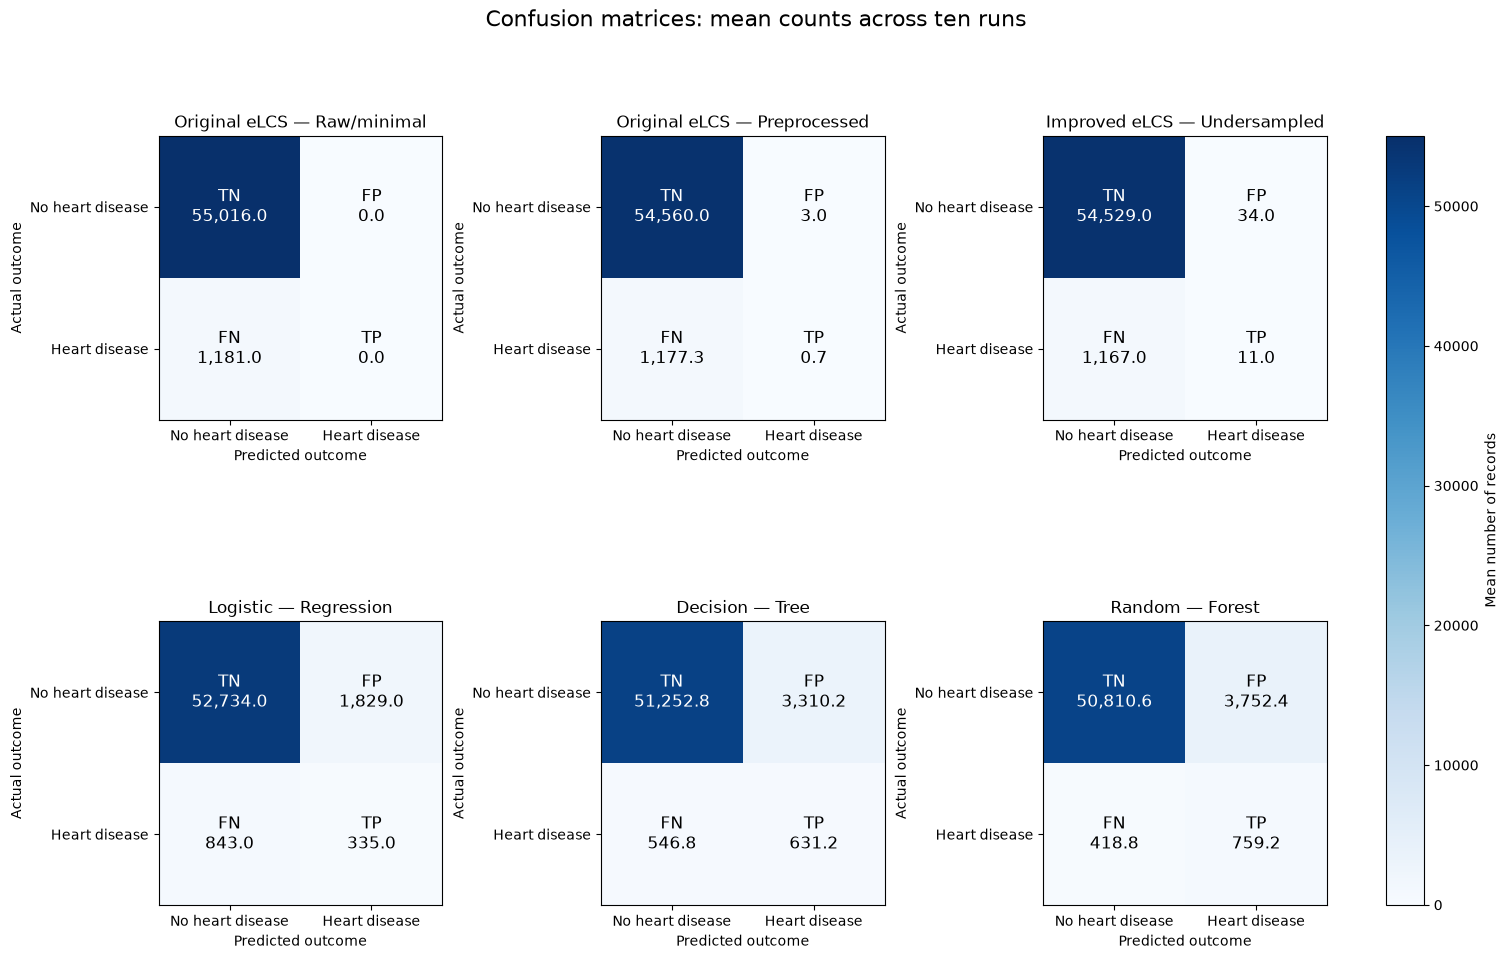

Graph saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison\confusion_matrix_mean_counts.png


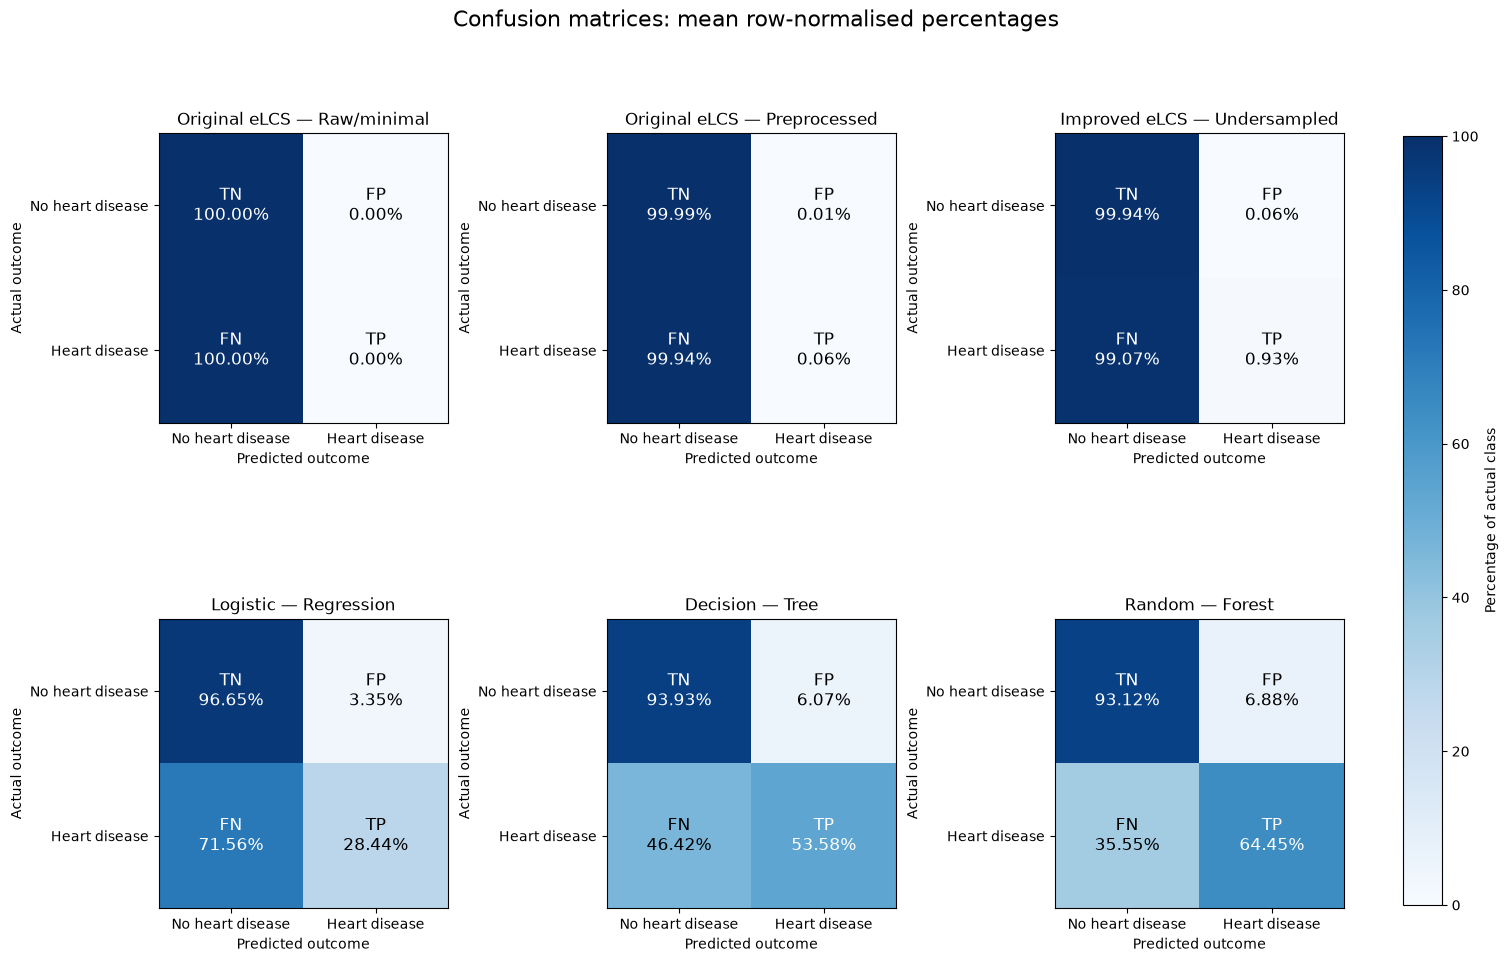

Graph saved to: c:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\outputs\model_comparison\confusion_matrix_row_percentages.png


In [11]:
import matplotlib.pyplot as plt

confusion_columns = [
    "True negatives",
    "False positives",
    "False negatives",
    "True positives",
]

mean_matrices = {}
percentage_matrices = {}

for model_name, results in model_results.items():
    counts = results[confusion_columns].to_numpy(dtype=float)

    assert np.isfinite(counts).all(), (
        f"{model_name}: missing or invalid confusion counts."
    )
    assert (counts >= 0).all(), (
        f"{model_name}: negative confusion counts."
    )

    # Each run becomes:
    # [[true negatives, false positives],
    #  [false negatives, true positives]]
    run_matrices = counts.reshape(-1, 2, 2)

    mean_matrices[model_name] = run_matrices.mean(axis=0)

    # Normalises each actual-class row within each run,
    # then averages those percentages across runs.
    row_totals = run_matrices.sum(axis=2, keepdims=True)
    assert (row_totals > 0).all(), (
        f"{model_name}: an actual class has no records."
    )

    percentage_matrices[model_name] = (
        run_matrices / row_totals * 100
    ).mean(axis=0)


def plot_confusion_comparison(matrices, title, filename, percentages=False):
    fig, axes = plt.subplots(
        2, 3, figsize=(15, 10), layout="constrained"
    )

    # Shared colour scale allows comparison between models.
    maximum = (
        100 if percentages
        else max(matrix.max() for matrix in matrices.values())
    )

    for axis, (model_name, matrix) in zip(axes.flat, matrices.items()):
        image = axis.imshow(
            matrix,
            cmap="Blues",
            vmin=0,
            vmax=maximum,
        )

        axis.set_title(model_name.replace("\n", " — "))
        axis.set_xlabel("Predicted outcome")
        axis.set_ylabel("Actual outcome")
        axis.set_xticks([0, 1])
        axis.set_yticks([0, 1])
        axis.set_xticklabels(["No heart disease", "Heart disease"])
        axis.set_yticklabels(["No heart disease", "Heart disease"])

        cell_names = [["TN", "FP"], ["FN", "TP"]]

        for row in range(2):
            for column in range(2):
                value = matrix[row, column]
                label = (
                    f"{value:.2f}%"
                    if percentages
                    else f"{value:,.1f}"
                )

                axis.text(
                    column,
                    row,
                    f"{cell_names[row][column]}\n{label}",
                    ha="center",
                    va="center",
                    fontsize=12,
                    color="white" if value > maximum / 2 else "black",
                )

    fig.suptitle(title, fontsize=16)

    colour_bar = fig.colorbar(
        image,
        ax=list(axes.flat),
        shrink=0.8,
    )
    colour_bar.set_label(
        "Percentage of actual class"
        if percentages
        else "Mean number of records"
    )

    OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / filename

    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Graph saved to:", figure_path)


plot_confusion_comparison(
    mean_matrices,
    "Confusion matrices: mean counts across ten runs",
    "confusion_matrix_mean_counts.png",
)

plot_confusion_comparison(
    percentage_matrices,
    "Confusion matrices: mean row-normalised percentages",
    "confusion_matrix_row_percentages.png",
    percentages=True,
)

### 6.10 Compare mean precision–recall curves

Precision–recall curves are calculated separately for all ten seeds. Each curve is interpolated onto a common recall grid, allowing precision values to be averaged across runs. At duplicated recall values, the highest observed precision is retained for interpolation.

The lines show mean precision, while shaded regions show one standard deviation across runs. This shading describes run-to-run variation and is not a confidence interval.

Average precision (AP) is calculated separately for each run and summarised using its mean and standard deviation. These values are not calculated from the area under the interpolated mean curve.

The raw eLCS baseline recreates its train/test split for each seed, matching Task 2. The preprocessed models retain the fixed datasets used in Tasks 4 and 6. Their curves therefore reflect different evaluation protocols.

Training Original eLCS — raw/minimal, seed 3...
Completed: AP=0.2241
Training Original eLCS — preprocessed, seed 3...
Completed: AP=0.0519
Training Improved eLCS, seed 3...
Completed: AP=0.1788
Training Logistic Regression, seed 3...
Completed: AP=0.1247
Training Decision Tree, seed 3...
Completed: AP=0.1324
Training Random Forest, seed 3...
Completed: AP=0.1692


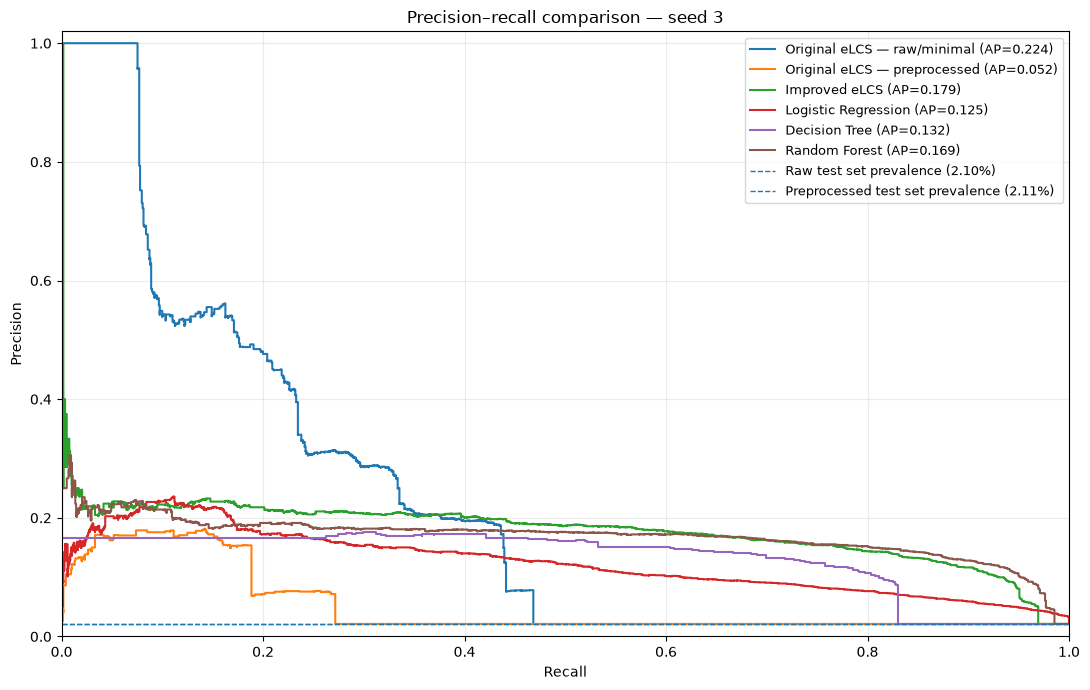

,Model,Seed,Average precision,Test prevalence,Test records
0,Original eLCS — raw/minimal,3,0.224123,0.021015,56197
1,Original eLCS — preprocessed,3,0.051937,0.021133,55741
2,Improved eLCS,3,0.178785,0.021133,55741
3,Logistic Regression,3,0.124663,0.021133,55741
4,Decision Tree,3,0.132446,0.021133,55741
5,Random Forest,3,0.169235,0.021133,55741


In [ ]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.exceptions import ConvergenceWarning

ELCS_ROOT = PROJECT_ROOT / "external" / "scikit-eLCS-master"

if not ELCS_ROOT.exists():
    raise FileNotFoundError(f"eLCS package not found: {ELCS_ROOT}")

if str(ELCS_ROOT) not in sys.path:
    sys.path.insert(0, str(ELCS_ROOT))

from skeLCS import eLCS

# Reuse scores only if the datasets and model settings are unchanged.
REUSE_SAVED_SCORES = True


def compare_mean_pr_curves():
    output_dir = PROJECT_ROOT / "outputs" / "model_comparison"
    score_dir = output_dir / "pr_scores"
    score_dir.mkdir(parents=True, exist_ok=True)

    # Loads the raw dataset for reproducing Task 2.
    raw = pd.read_csv(PROJECT_ROOT / "data" / "patient_data.csv")

    raw["heart_disease_target"] = raw["sublabel"].isin(
        ["HT", "DI_HT", "HT_HY", "DI_HT_HY"]
    ).astype(int)

    raw_features = raw.drop(columns=[
        "heart_disease_target",
        "sublabel",
        "disease_flags",
        "heart_disease",
    ])
    raw_target = raw["heart_disease_target"]

    categorical_columns = raw_features.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns.tolist()

    # Loads full preprocessed training data for original eLCS.
    full_train = pd.read_csv(
        PROJECT_ROOT / "data" / "X_train_preprocessed_full.csv"
    )
    full_target = pd.read_csv(
        PROJECT_ROOT / "data" / "y_train_preprocessed_full.csv"
    ).squeeze("columns")

    assert list(full_train.columns) == list(X_test.columns)
    assert list(X_train_undersampled.columns) == list(X_test.columns)
    assert len(full_train) == len(full_target)

    full_array = full_train.to_numpy(dtype=float)
    full_target_array = full_target.to_numpy(dtype=int)
    test_array = X_test.to_numpy(dtype=float)
    test_target = y_test.to_numpy(dtype=int)
    undersampled_array = X_train_undersampled.to_numpy(dtype=float)
    undersampled_target = y_train_undersampled.to_numpy(dtype=int)

    model_names = {
        "elcs_raw": "Original eLCS — raw/minimal",
        "elcs_preprocessed": "Original eLCS — preprocessed",
        "elcs_improved": "Improved eLCS",
        "logistic_regression": "Logistic Regression",
        "decision_tree": "Decision Tree",
        "random_forest": "Random Forest",
    }

    conventional_names = {
        "logistic_regression": "Logistic Regression",
        "decision_tree": "Decision Tree",
        "random_forest": "Random Forest",
    }

    recall_grid = np.linspace(0, 1, 1001)
    curves = {key: [] for key in model_names}
    run_rows = []

    for seed in SEEDS:
        for key, name in model_names.items():
            score_path = score_dir / f"{key}_seed_{seed}.npz"

            if REUSE_SAVED_SCORES and score_path.exists():
                print(f"Loading {name}, seed {seed}", flush=True)

                with np.load(score_path) as saved:
                    actual = saved["y_true"].reshape(-1)
                    scores = saved["probabilities"].reshape(-1)

                if key != "elcs_raw":
                    assert np.array_equal(actual, test_target), (
                        f"{name}: saved test labels differ. "
                        "Set REUSE_SAVED_SCORES=False."
                    )

            else:
                print(f"Training {name}, seed {seed}...", flush=True)

                if key == "elcs_raw":
                    # Recreates Task 2's split for the current seed.
                    train, test, train_y, actual = train_test_split(
                        raw_features,
                        raw_target,
                        test_size=0.20,
                        random_state=seed,
                        stratify=raw_target,
                        shuffle=True,
                    )

                    train = train.copy()
                    test = test.copy()

                    encoder = OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    )
                    train[categorical_columns] = encoder.fit_transform(
                        train[categorical_columns]
                    )
                    test[categorical_columns] = encoder.transform(
                        test[categorical_columns]
                    )

                    train = train.to_numpy(dtype=float)
                    test = test.to_numpy(dtype=float)
                    train_y = train_y.to_numpy(dtype=int)
                    actual = actual.to_numpy(dtype=int)
                    model = eLCS(random_state=seed)

                elif key == "elcs_preprocessed":
                    train = full_array
                    train_y = full_target_array
                    test = test_array
                    actual = test_target
                    model = eLCS(random_state=seed)

                elif key == "elcs_improved":
                    train = undersampled_array
                    train_y = undersampled_target
                    test = test_array
                    actual = test_target
                    model = eLCS(
                        N=8000,
                        learning_iterations=50000,
                        random_state=seed,
                    )

                else:
                    train = X_train_undersampled
                    train_y = y_train_undersampled
                    test = X_test
                    actual = test_target
                    model = create_models(seed)[conventional_names[key]]

                with warnings.catch_warnings():
                    warnings.simplefilter("error", ConvergenceWarning)
                    model.fit(train, train_y)

                positive_column = (
                    1 if key.startswith("elcs_")
                    else int(np.flatnonzero(model.classes_ == 1)[0])
                )

                scores = model.predict_proba(test)[:, positive_column]

                # Saves each completed run for reuse after interruptions.
                np.savez_compressed(
                    score_path,
                    y_true=actual,
                    probabilities=scores,
                )

            assert len(actual) == len(scores)
            assert set(np.unique(actual)) == {0, 1}
            assert np.isfinite(scores).all()
            assert ((scores >= 0) & (scores <= 1)).all()

            precision, recall, _ = precision_recall_curve(actual, scores)
            ap = average_precision_score(actual, scores)

            # Removes duplicate recall positions before interpolation.
            curve_points = (
                pd.DataFrame({
                    "Recall": recall,
                    "Precision": precision,
                })
                .groupby("Recall", sort=True)["Precision"]
                .max()
            )

            aligned_precision = np.interp(
                recall_grid,
                curve_points.index.to_numpy(),
                curve_points.to_numpy(),
            )
            curves[key].append(aligned_precision)

            run_rows.append({
                "Model": name,
                "Seed": seed,
                "Average precision": ap,
                "Test prevalence": float(actual.mean()),
                "Test records": len(actual),
            })

            # Retains progress in the summary as well as score files.
            pd.DataFrame(run_rows).to_csv(
                output_dir / "precision_recall_runs.csv",
                index=False,
            )

            print(f"Completed: AP={ap:.4f}", flush=True)

    runs = pd.DataFrame(run_rows)
    summary = (
        runs.groupby("Model", sort=False)["Average precision"]
        .agg(["count", "mean", "std"])
        .rename(columns={
            "count": "Runs",
            "mean": "Mean AP",
            "std": "AP standard deviation",
        })
        .reset_index()
    )

    colours = [
        "#7F7F7F", "#56B4E9", "#0072B2",
        "#E69F00", "#009E73", "#CC79A7",
    ]

    fig, axis = plt.subplots(figsize=(12, 8))
    grid_rows = []

    for (key, name), colour in zip(model_names.items(), colours):
        aligned_curves = np.asarray(curves[key])
        assert aligned_curves.shape[0] == len(SEEDS)

        mean_precision = aligned_curves.mean(axis=0)
        std_precision = aligned_curves.std(axis=0, ddof=1)

        ap_values = runs.loc[
            runs["Model"] == name, "Average precision"
        ]
        mean_ap = ap_values.mean()
        std_ap = ap_values.std(ddof=1)

        axis.plot(
            recall_grid,
            mean_precision,
            color=colour,
            linewidth=2,
            label=f"{name} (AP={mean_ap:.3f} ± {std_ap:.3f})",
        )

        axis.fill_between(
            recall_grid,
            np.clip(mean_precision - std_precision, 0, 1),
            np.clip(mean_precision + std_precision, 0, 1),
            color=colour,
            alpha=0.10,
        )

        grid_rows.append(pd.DataFrame({
            "Model": name,
            "Recall": recall_grid,
            "Mean precision": mean_precision,
            "Precision standard deviation": std_precision,
        }))

    # Shows the prevalence reference for each evaluation protocol.
    raw_prevalence = runs.loc[
        runs["Model"] == model_names["elcs_raw"], "Test prevalence"
    ].mean()

    references = {
        "Raw test sets: mean prevalence": raw_prevalence,
        "Preprocessed test set prevalence": float(test_target.mean()),
    }

    for label, prevalence in references.items():
        axis.axhline(
            prevalence,
            linestyle="--",
            linewidth=1,
            label=f"{label} ({prevalence:.2%})",
        )

    axis.set(
        xlabel="Recall",
        ylabel="Precision",
        title="Mean precision–recall curves across ten seeds",
        xlim=(0, 1),
        ylim=(0, 1.02),
    )
    axis.grid(alpha=0.25)
    axis.legend(loc="best", fontsize=9)
    fig.tight_layout()

    fig.savefig(
        output_dir / "precision_recall_mean_curves.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    summary.to_csv(
        output_dir / "precision_recall_mean_summary.csv",
        index=False,
    )
    pd.concat(grid_rows, ignore_index=True).to_csv(
        output_dir / "precision_recall_mean_curve_points.csv",
        index=False,
    )

    display(summary)
    return runs, summary


pr_curve_runs, pr_curve_summary = compare_mean_pr_curves()

### 6.11 Compare training time

Training time is compared across the six models using the mean duration across ten runs. Error bars represent one standard deviation, showing variation in recorded training time.

Logistic Regression timing includes fitting its standardisation pipeline. Random Forest uses parallel processing, so these results compare elapsed time under the recorded configurations rather than equal computational resources. Timing is also affected by hardware and other processes running during the experiments.

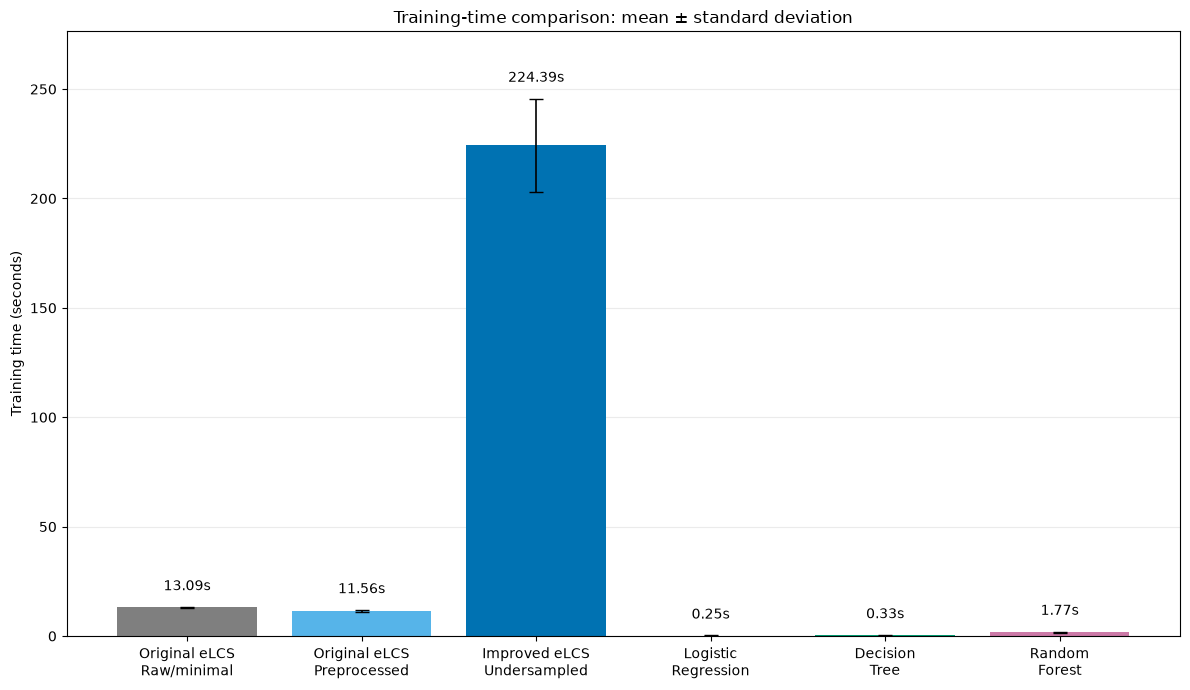

,Model,Mean seconds,Standard deviation,Minimum seconds,Maximum seconds
0,Original eLCS\nRaw/minimal,13.091345,0.186924,12.765835,13.357953
1,Original eLCS\nPreprocessed,11.561169,0.365769,11.185162,12.375019
2,Improved eLCS\nUndersampled,224.387434,21.296680,196.601141,272.024565
3,Logistic\nRegression,0.246905,0.052793,0.198581,0.350887
4,Decision\nTree,0.327890,0.143005,0.165402,0.554043
5,Random\nForest,1.765678,0.271097,1.432892,2.227363


In [15]:
import matplotlib.pyplot as plt

timing_rows = []

for model_name, results in model_results.items():
    times = results["Training seconds"].to_numpy(dtype=float)

    assert len(times) == len(SEEDS)
    assert np.isfinite(times).all()
    assert (times >= 0).all()

    timing_rows.append({
        "Model": model_name,
        "Mean seconds": times.mean(),
        "Standard deviation": times.std(ddof=1),
        "Minimum seconds": times.min(),
        "Maximum seconds": times.max(),
    })

timing_summary = pd.DataFrame(timing_rows)

colours = [
    "#7F7F7F",
    "#56B4E9",
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#CC79A7",
]

fig, axis = plt.subplots(figsize=(12, 7))
positions = np.arange(len(timing_summary))

bars = axis.bar(
    positions,
    timing_summary["Mean seconds"],
    yerr=timing_summary["Standard deviation"],
    color=colours[:len(timing_summary)],
    capsize=5,
    error_kw={"elinewidth": 1.2},
)

axis.set_xticks(positions)
axis.set_xticklabels(timing_summary["Model"], fontsize=10)
axis.set_ylabel("Training time (seconds)")
axis.set_title(
    "Training-time comparison: mean ± standard deviation"
)
axis.set_axisbelow(True)
axis.grid(axis="y", alpha=0.25)

# Adds labels above the error bars.
upper_values = (
    timing_summary["Mean seconds"]
    + timing_summary["Standard deviation"]
)
padding = max(float(upper_values.max()) * 0.025, 0.01)

for bar, mean, upper in zip(
    bars,
    timing_summary["Mean seconds"],
    upper_values,
):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        upper + padding,
        f"{mean:.2f}s",
        ha="center",
        va="bottom",
    )

axis.set_ylim(0, float(upper_values.max()) + padding * 5)
fig.tight_layout()

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "model_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    OUTPUT_DIR / "training_time_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

display(timing_summary)

timing_summary.to_csv(
    OUTPUT_DIR / "training_time_summary.csv",
    index=False,
)